<a href="https://colab.research.google.com/github/intercambioca-creator/curso-aleman-ia-demo/blob/main/prueba_personas_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Segmentación de Instancia con Mask R-CNN (Capacitación)

Este cuaderno explica cómo usar un modelo preentrenado de Mask R-CNN para:
- Detectar objetos en imágenes.
- Generar máscaras de segmentación.
- Visualizar y recortar objetos.
- Aplicar la técnica en contextos comunitarios y educativos.


In [5]:
# 1. Instalar dependencias (solo en Colab)
!pip install torch torchvision matplotlib pillow

# 2. Importar librerías
import torch
import torchvision
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np


In [6]:
# 3. Cargar modelo preentrenado
model = torchvision.models.detection.maskrcnn_resnet50_fpn(
    weights=torchvision.models.detection.MaskRCNN_ResNet50_FPN_Weights.DEFAULT
)
model.eval()


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [7]:
# 4. Cargar y transformar imagen
# Sube tu propia imagen en Colab (ejemplo: personas.jpg)
from google.colab import files
uploaded = files.upload()

img = Image.open(list(uploaded.keys())[0])
transform = transforms.Compose([transforms.ToTensor()])
img_tensor = transform(img)


Saving Zertifikat_5.jpeg to Zertifikat_5 (1).jpeg


In [8]:
# 5. Ejecutar inferencia
with torch.no_grad():
    predictions = model([img_tensor])

masks = predictions[0]['masks']
labels = predictions[0]['labels']
scores = predictions[0]['scores']


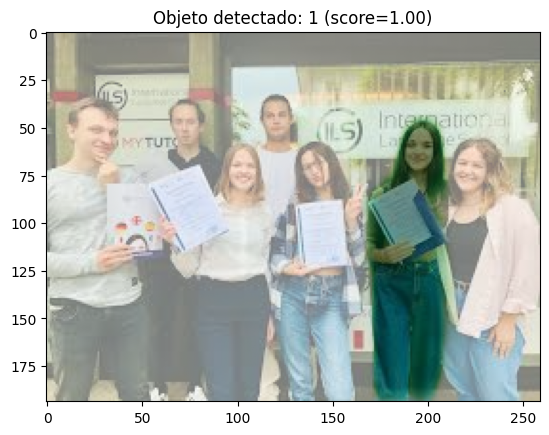

In [9]:
# 6. Visualización
plt.imshow(img)
plt.imshow(masks[0, 0], alpha=0.5, cmap="Greens")
plt.title(f"Objeto detectado: {labels[0].item()} (score={scores[0]:.2f})")
plt.show()


In [7]:
# 7. Recorte del objeto
mask = masks[0, 0].mul(255).byte().cpu().numpy()
img_array = np.array(img)

segmented = np.zeros_like(img_array)
segmented[mask > 128] = img_array[mask > 128]

Image.fromarray(segmented).save("objeto_segmentado.png")


## Ejercicio práctico
1. Sube una imagen propia (ejemplo: plantas, personas, objetos locales).
2. Ejecuta el flujo completo.
3. Documenta los resultados en la plantilla compartida.
4. Reflexiona sobre aplicaciones comunitarias (conteo de árboles, identificación de especies, etc.).
